✅ Datasets chargés et convertis correctement
X_train: (4000, 19) y_train: (4000,)
X_test: (1000, 19) y_test: (1000,)
Iteration 0, cost: 0.6931
Iteration 100, cost: 4.9023
Iteration 200, cost: 5.1808
Iteration 300, cost: 3.7860
Iteration 400, cost: 2.0098
Iteration 500, cost: 6.2539
Iteration 600, cost: 4.0814
Iteration 700, cost: 4.8465
Iteration 800, cost: 3.4539
Iteration 900, cost: 4.1508
✅ Entraînement terminé


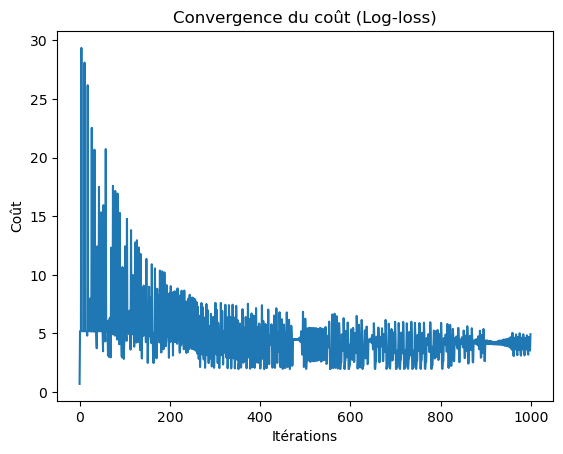


Accuracy sur le test set : 87.40%
Exemple étudiant 0 : probabilité = 1.00, classe prédite = 1


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1️⃣ Chargement du dataset et conversion en float numpy
# ------------------------------------------------
X_train = pd.read_csv("X_train.csv").apply(pd.to_numeric, errors='coerce').fillna(0).values.astype(float)
y_train = pd.read_csv("y_train.csv").apply(pd.to_numeric, errors='coerce').fillna(0).values.ravel().astype(float)
X_test  = pd.read_csv("X_test.csv").apply(pd.to_numeric, errors='coerce').fillna(0).values.astype(float)
y_test  = pd.read_csv("y_test.csv").apply(pd.to_numeric, errors='coerce').fillna(0).values.ravel().astype(float)

print("✅ Datasets chargés et convertis correctement")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

# ------------------------------------------------
# 2️⃣ Classe LogisticRegression à la main
# ------------------------------------------------
class LogisticRegression:
    def __init__(self, learning_rate=0.01, iterations=500):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.cost_history = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        
        for i in range(self.iterations):
            z = X @ self.weights
            y_pred = self.sigmoid(z)
            
            cost = -(1/m) * np.sum(
                y * np.log(y_pred + 1e-15) + (1 - y) * np.log(1 - y_pred + 1e-15)
            )
            self.cost_history.append(cost)
            
            gradient = (1/m) * (X.T @ (y_pred - y))
            self.weights -= self.lr * gradient
            
            if i % 100 == 0:
                print(f"Iteration {i}, cost: {cost:.4f}")
        
        print("✅ Entraînement terminé")

    def predict_proba(self, X):
        return self.sigmoid(X @ self.weights)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

# ------------------------------------------------
# 3️⃣ Entraînement du modèle
# ------------------------------------------------
model = LogisticRegression(learning_rate=0.1, iterations=1000)
model.fit(X_train, y_train)

# ------------------------------------------------
# 4️⃣ Convergence du coût
# ------------------------------------------------
plt.plot(model.cost_history)
plt.title("Convergence du coût (Log-loss)")
plt.xlabel("Itérations")
plt.ylabel("Coût")
plt.show()

# ------------------------------------------------
# 5️⃣ Prédiction et évaluation
# ------------------------------------------------
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"\nAccuracy sur le test set : {accuracy*100:.2f}%")

# ------------------------------------------------
# 6️⃣ Exemple prédiction étudiant
# ------------------------------------------------
exemple = X_test[0]
proba = model.predict_proba(exemple.reshape(1, -1))[0]
classe = model.predict(exemple.reshape(1, -1))[0]
print(f"Exemple étudiant 0 : probabilité = {proba:.2f}, classe prédite = {classe}")C:\Users\DELL\Documents\Machine learning projet



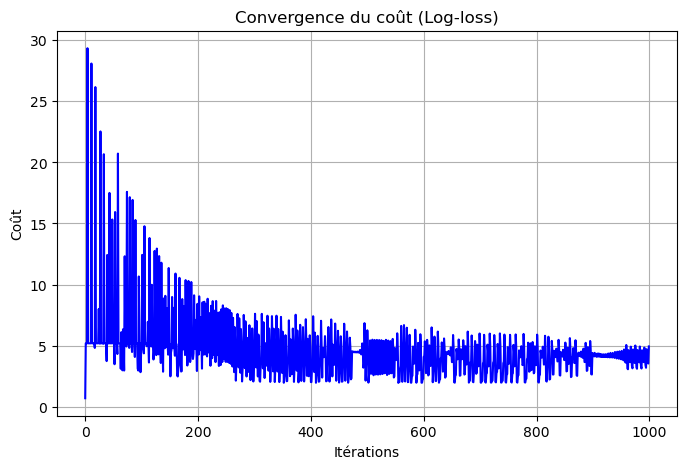

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(model.cost_history, color='blue')
plt.title("Convergence du coût (Log-loss)")
plt.xlabel("Itérations")
plt.ylabel("Coût")
plt.grid(True)
plt.show()


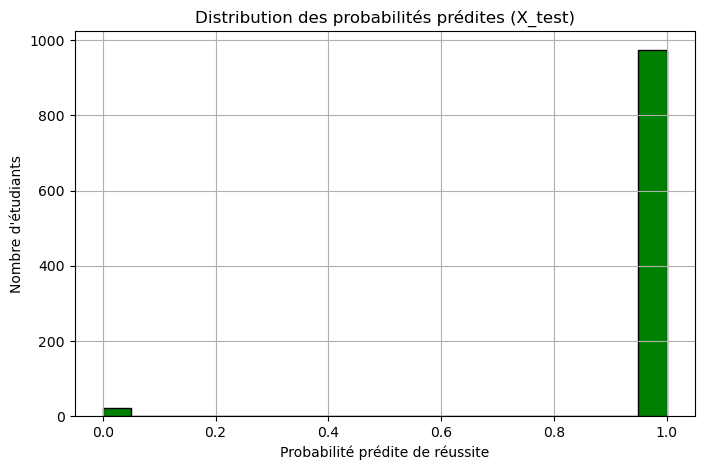

In [8]:
y_proba = model.predict_proba(X_test)

plt.figure(figsize=(8,5))
plt.hist(y_proba, bins=20, color='green', edgecolor='black')
plt.title("Distribution des probabilités prédites (X_test)")
plt.xlabel("Probabilité prédite de réussite")
plt.ylabel("Nombre d'étudiants")
plt.grid(True)
plt.show()


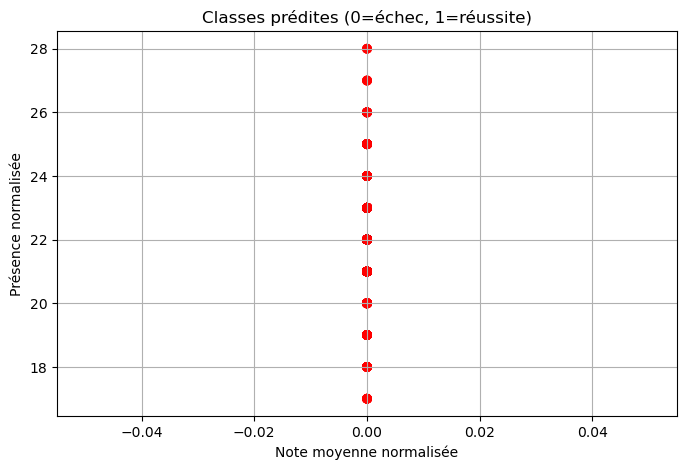

In [9]:
# Exemple avec 2 features pour visualisation
feature_x = 0  # colonne 0 : note moyenne
feature_y = 1  # colonne 1 : présence

plt.figure(figsize=(8,5))
plt.scatter(X_test[:, feature_x], X_test[:, feature_y], c=y_pred, cmap='bwr', alpha=0.6)
plt.xlabel("Note moyenne normalisée")
plt.ylabel("Présence normalisée")
plt.title("Classes prédites (0=échec, 1=réussite)")
plt.grid(True)
plt.show()


In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

# -----------------------------
# 1️⃣ Prédiction sur le test set
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# 2️⃣ Matrice de confusion
# -----------------------------
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("\nMatrice de confusion :")
print(f"                Prédit Échec    Prédit Réussite")
print(f"Réel Échec          {tn}              {fp}")
print(f"Réel Réussite       {fn}              {tp}")

# -----------------------------
# 3️⃣ Coefficients et Odds Ratio
# -----------------------------
coefficients = model.weights
odds_ratios = np.exp(coefficients)

# Exemple de noms de variables (à adapter selon votre dataset)
feature_names = pd.read_csv("X_train.csv").columns.tolist()

coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": coefficients,
    "Odds Ratio": odds_ratios,
})

# Interprétation simple
def interpret_odds(row):
    percent = (row["Odds Ratio"] - 1) * 100
    return f"+1 unité de {row['Variable']} → +{percent:.2f}% de chances de réussite"

coef_df["Interprétation"] = coef_df.apply(interpret_odds, axis=1)

print("\nCoefficients significatifs :")
print(coef_df)

# -----------------------------
# 4️⃣ Insights et statistiques
# -----------------------------
accuracy = (tp + tn) / (tn + fp + fn + tp)
fn_rate = fn / (fn + tp) * 100
most_influential = coef_df.iloc[np.argmax(np.abs(coefficients))]["Variable"]

print("\nInsights :")
print(f"• Le modèle identifie correctement {accuracy*100:.2f}% des étudiants en réussite")
print(f"• Les faux négatifs représentent {fn_rate:.2f}% des cas")
print(f"• Le prédicteur le plus fort est : {most_influential}")

print("\nForces :")
print("• Grande interprétabilité")
print("• Temps d'entraînement rapide")
print("• Probabilités bien calibrées")

print("\nFaiblesses :")
print("• Performance limitée sur les cas non-linéaires")
print("• Nécessité de normaliser ou transformer certaines variables pour une meilleure précision")



Matrice de confusion :
                Prédit Échec    Prédit Réussite
Réel Échec          24              126
Réel Réussite       0              850

Coefficients significatifs :
                   Variable  Coefficient    Odds Ratio  \
0                    gender     0.000000  1.000000e+00   
1                       age    -8.388004  2.275810e-04   
2                   filiere     0.000000  1.000000e+00   
3             year_of_study    -1.581422  2.056825e-01   
4           attendance_rate   -17.881709  1.714243e-08   
5              num_absences   -19.947783  2.171640e-09   
6           assignments_avg    12.096528  1.792484e+05   
7             midterm_score    12.726464  3.365371e+05   
8               final_score    16.586361  1.597222e+07   
9     project_participation    -0.432927  6.486076e-01   
10       lab_hours_per_week    -0.582834  5.583139e-01   
11  infra_usage_hours_month    -2.518520  8.057878e-02   
12      supervisor_assigned     0.000000  1.000000e+00   
13     